In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
trade_history = pd.read_csv('data/processed.csv')

## Month Based Analysis

In [3]:
# overall totals without classification
overall = trade_history.groupby(
    'month'
).agg({
    'Trade ID': 'count',
    'Closed PnL': ['sum', 'mean']
})

overall

Trade ID    Closed PnL           
         count           sum       mean
month                                  
1        22017  7.546599e+05  34.276239
2        46726  2.446842e+06  52.365743
3        42459  2.278234e+06  53.657262
4        53551  1.323610e+06  24.716808
5         2502  8.386787e+04  33.520333
6         2187  1.029840e+05  47.089156
7         2526  1.385624e+05  54.854472
8         1262 -1.068172e+05 -84.641229
9          510  4.823575e+04  94.579902
10         715  4.379193e+04  61.247451
11        6538  1.334300e+05  20.408386
12       30225  3.007087e+06  99.490062

## Key Insights: Monthly Trading Patterns

- `December (12)` was the strongest trading month:
  - **$3.01M total pnl**
  - **$99.49 avg pnl**
  - across **30.2K trades**

- Highest trading activity occurred during:
  - `April (4)` → **53.6K trades**
  - `February (2)` → **46.7K trades**
  - `March (3)` → **42.5K trades**

- High trade volume did not correspond to higher profitability:
  - `April` had the highest activity but only:
    - **$24.72 avg pnl**
  - `December` generated nearly:
    - **4x higher avg pnl**

- `August (8)` was the only loss-making month:
  - **-$84.64 avg pnl**
  - **-$106.8K total pnl**

- `September (9)` showed the highest avg profitability:
  - **$94.58 avg pnl**
  - despite only **510 trades**

- Early-year periods (`February–March`) maintained consistently strong profitability:
  - Avg pnl above **$52**

- Trading profitability declined significantly during mid-year periods before recovering strongly in `December`.

Text(0.5, 1.0, 'Month Based Trade Count by Sentiment')

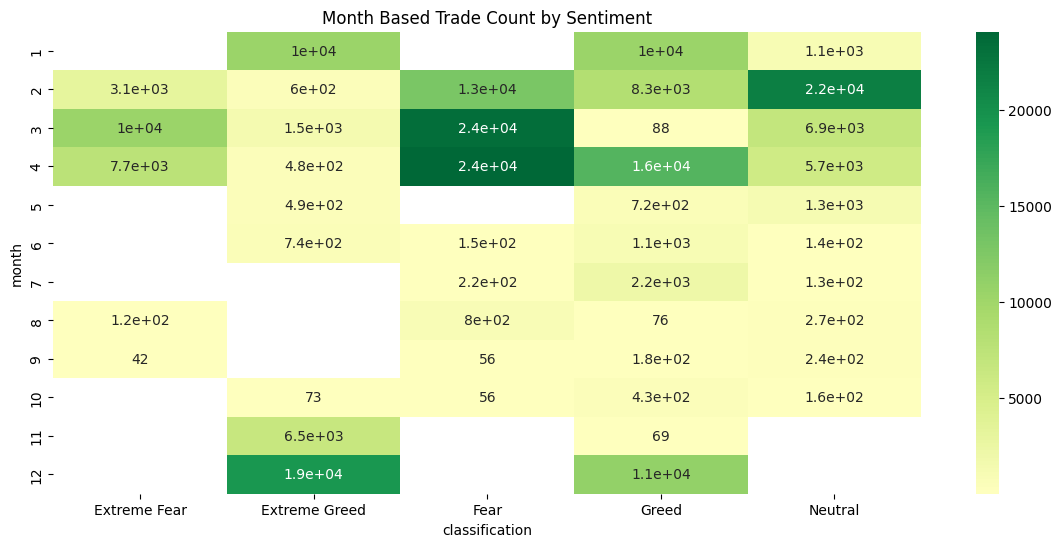

In [4]:
month_trade_count = trade_history.pivot_table(
    values='Trade ID',
    index='month',
    columns='classification',
    aggfunc='count'
)

# week_trade_count

plt.figure(figsize=(14,6))

sns.heatmap(
    month_trade_count,
    cmap='RdYlGn',
    center=0,
    annot=True
)

plt.title("Month Based Trade Count by Sentiment")

## Key Insights: Month-Based Trade Count by Sentiment

### Fear
- Dominated trading activity throughout the year.
- Highest participation:
  - `March (3)` → **24K trades**
  - `April (4)` → **24K trades**
  - `February (2)` → **13K trades**

### Extreme Greed
- Strong trading spikes observed during:
  - `December (12)` → **19K trades**
  - `January (1)` → **10K trades**

### Greed
- Peak participation:
  - `April (4)` → **16K trades**
  - `December (12)` → **11K trades**

### Neutral
- Highest activity:
  - `February (2)` → **22K trades**
- Participation declined sharply after early-year periods.

### Extreme Fear
- Generally maintained the lowest market participation.
- Highest activity:
  - `March (3)` → **10K trades**
  - `April (4)` → **7.7K trades**

- Trading activity was heavily concentrated during early-year (`February–April`) and year-end (`December`) periods.
- Fear and Greed regimes consistently generated the highest overall market participation.

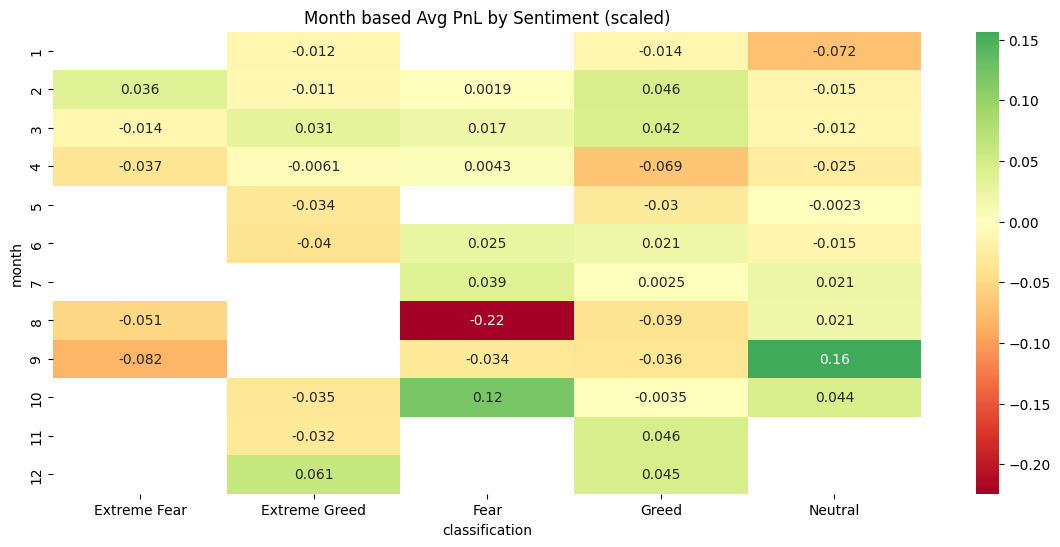

In [5]:
month_profit_pivot = trade_history.pivot_table(
    values='Scaled PnL',
    index='month',
    columns='classification',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))

sns.heatmap(
    month_profit_pivot,
    cmap='RdYlGn',
    center=0,
    annot=True
)

plt.title("Month based Avg PnL by Sentiment (scaled)")
plt.show()

## Key Insights: Month-Based Avg PnL by Sentiment

### Fear
- Strongest profitability:
  - `October (10)` → **0.12 scaled avg pnl**
- Worst performance:
  - `August (8)` → **-0.22** (lowest overall)

### Neutral
- Highest profitability across all regimes:
  - `September (9)` → **0.16 scaled avg pnl**
- Additional strength:
  - `October (10)` → **0.044**

### Extreme Greed
- Best performance:
  - `December (12)` → **0.061**
- Weakest periods:
  - `June (6)` → **-0.039**
  - `October (10)` → **-0.035**

### Greed
- Strong profitability observed during:
  - `November (11)` → **0.047**
  - `February (2)` → **0.046**
- Weakest month:
  - `April (4)` → **-0.068**

### Extreme Fear
- Mostly weak profitability throughout the year.
- Worst period:
  - `September (9)` → **-0.082**

- Fear sentiment showed the highest monthly pnl volatility across all sentiment regimes.
- Mid-to-late year periods exhibited stronger pnl instability compared to early-year periods.